# Decision Tree

Decision tree is a tree-based algorithm uses to predict a categorical target variable and can capture complex and non-linear patterns. In this section we're talking about the **Classification Decision Tree**, so using **Regression Decision Tree** we can do regression tasks too.

The first concept in the decision trees are the tree nodes:
- Root Node
- Intermediate Node
- Leaf Node

Building a decision tree folows a **top-down induction** process, We start by a root node that is a feature then using braching we split the data and repeating this process utill reaching the leaf nodes that are the predictions that we make using our model (Using majority voting).

Another concept in the decision trees is that we split the data using **recursive partitioning**. 


## Splitting Criteria

We use ways to select the feature that seperate the data the most to take as the node in each step so we can make an optimized tree not just a predictive model, So the splitting criteria plays the oprtimization process role in the decision trees. There are two main ways to split the data, using:
- **Gini Impurity**
- **Entropy** & **Information Gain**

Using these measures of impurity we can find the feature that has the lowest impurity or has the highest information gain so we can go from the impurity to the pure space that we can try to classify the target variable in this way (in the real-world we can see this in entropy concept that if we want to move from impurity to purity - that is not the natural process in the world- we should use energy).


Formulas in binary classification:
$$
	\text{Gini Impurity} = 1 - (p_+^2) - (p_-^2) \\
	\text{ } \\
	\text{Entropy} = p_+\log(p_+) + p_-\log(p_-)
$$

**comparison:**
- Interpretability --> Entropy
- Sensitivity --> Entropy is more sensitive to number of categories
- More Computationally Efficient --> Gini Impurity


> **Note:** Entropy tends to favor features with more categories, but Gini Impurity is less sensitive to the number of the categories.

> **Note:** Gini Impurity tends to isolate the most frequent class in its own branch of the tree, while Entropy tends to produce more balanced trees.

## Stopping criteria

So to prevent overfitting and to make our model stop growing the tree we have bunch of stopping criteria:
- **Maximum Depth**
- **Minimum Number of Samples** --> commonly `20`
- **Minimum Impurity Decrease**
- **Pure Node**

We can use each of these criteria or a combination of them to reach the performance we want from our model.

## Building a model

We can say we start the top-down induction process and use recursive partitioning to split the data and increase the purity from the impure and chaotic data, In choosing the best feature (or feature with boudary) we use a splitting criterion and then grow our tree. We need a measure where to stop the learning (growing the tree) so we use a stopping criterion or a combination of stopping criteria to make the model stop training at a place.

**Just building a model is not enough we need to train a model that can generalize well to the unseen data.**

## Pruning

Pruning is a optimization technique in decision trees and we use this to prevent our model from overfitting to the data just like regularization techniques.

**Different Types of Pruning:**
- **Pre-Pruning**
	- Maximum Depth
	- Minimum Samples per Split
	- Minimum Sample per Leaf
	- Maximum Features --> introduces randomness to the model (increase bias)
- **Post-Pruning**
	- Cost Complexity Performance (CCP) --> most important one
	- Minimum Impurity Decrease
	- Minimum Laef Size

We can say stopping criteria used as pruning technique specialy as a pre-pruning technique, so we can control the growth of the model and train more stable models and models that perform better on the prediction of unseen data.

**Benefits of pruning a decision tree model:**
- Can improve the generalization of the model
- More interpretable model
- Reduce the complexity of the model so results in a more efficient model

## Cons & Pros:

**Pros:**
- Interpretable
- No Assumptions Made
- Can Capture Complex Patterns
- Can Have Better Predictive Performance than Linear Models
- Feature Importance
- No Need to Standardized Features 

**Cons:**
- Overfitting Prone
- Needs Hyperparameter Tuning
- More Computationaly Expensive than Linear Models
- Grid-Like Decision Boundaries

## Examples

In [1]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# load data
X, y = load_iris(return_X_y=True, as_frame=True)

# splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# training model (Pre-Pruning used: minimum samples per leaf)
tree = DecisionTreeClassifier(criterion="gini", min_samples_leaf=7, random_state=42)
tree.fit(X_train, y_train)

,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",7
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

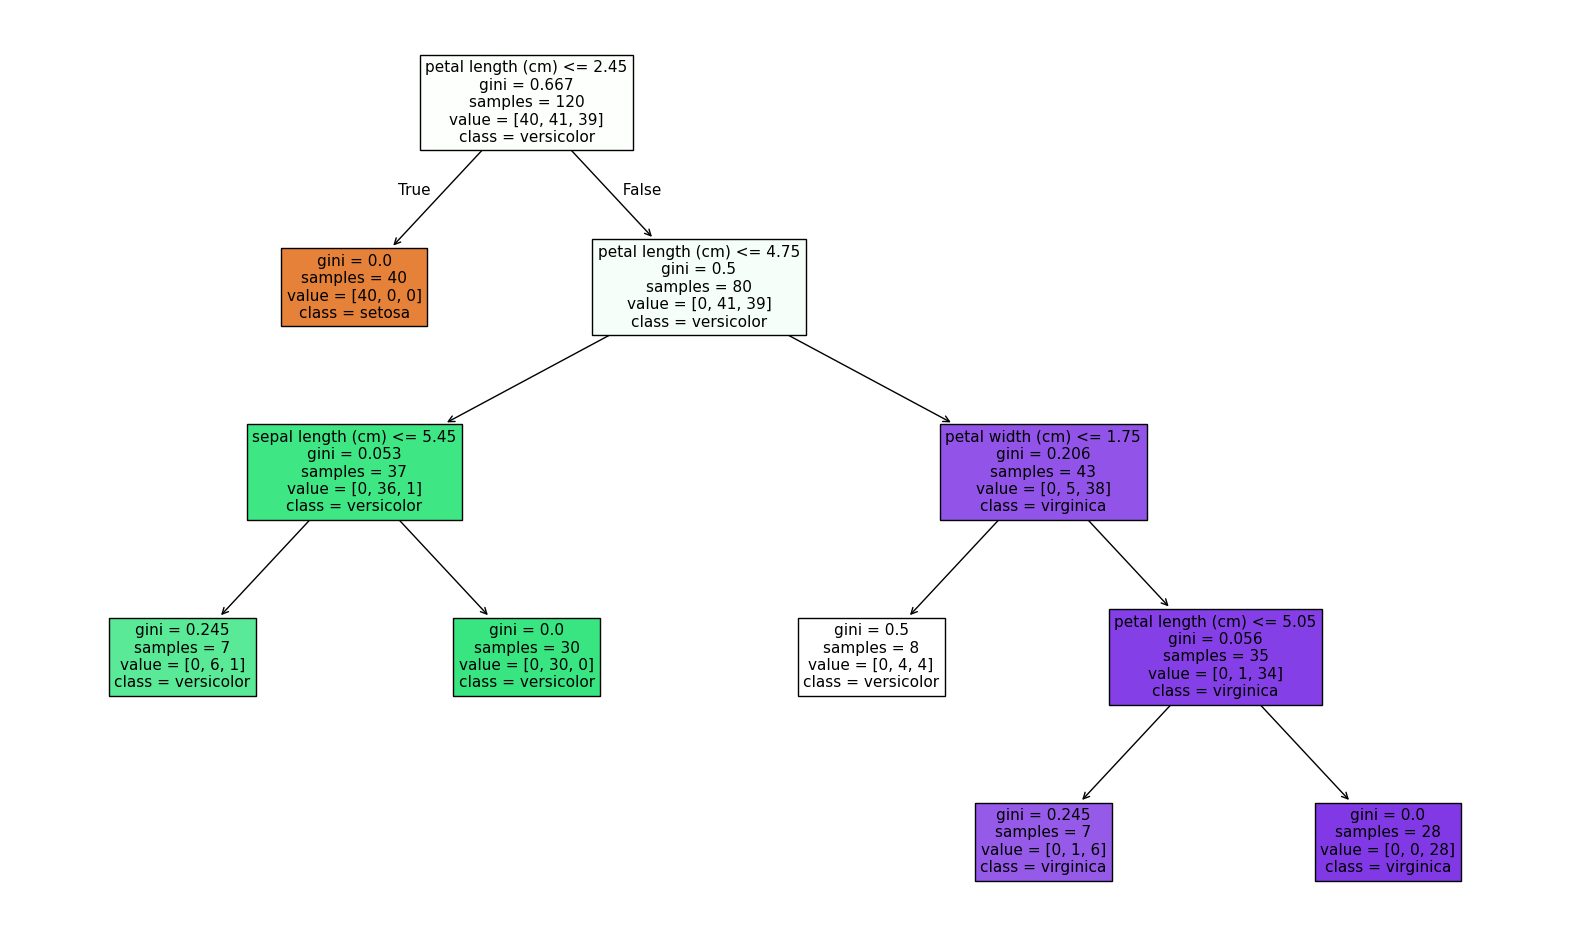

In [32]:
_, ax = plt.subplots(figsize=(20, 12))

plot_tree(
    decision_tree=tree,
    filled=True,
    fontsize=11,
    feature_names=X.columns,
    class_names=load_iris().target_names
)
plt.show()

In [28]:
y_pred = tree.predict(X_test)

acc = accuracy_score(y_true=y_test, y_pred=y_pred)
f1 = f1_score(y_true=y_test, y_pred=y_pred, average="macro")

print(f"Accuracy Score: {acc}")
print(f"F1-Score: {f1}")

Accuracy Score: 1.0
F1-Score: 1.0


In [64]:
# Post-pruning a decision tree using CCP (cost complexity pruning)
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# loading data
X, y = load_breast_cancer(return_X_y=True, as_frame=True)

# splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# model training
tree = DecisionTreeClassifier(criterion="gini", random_state=42)
tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [65]:
y_pred = tree.predict(X_val)

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.94      0.88        36
           1       0.96      0.87      0.91        55

    accuracy                           0.90        91
   macro avg       0.89      0.91      0.90        91
weighted avg       0.91      0.90      0.90        91



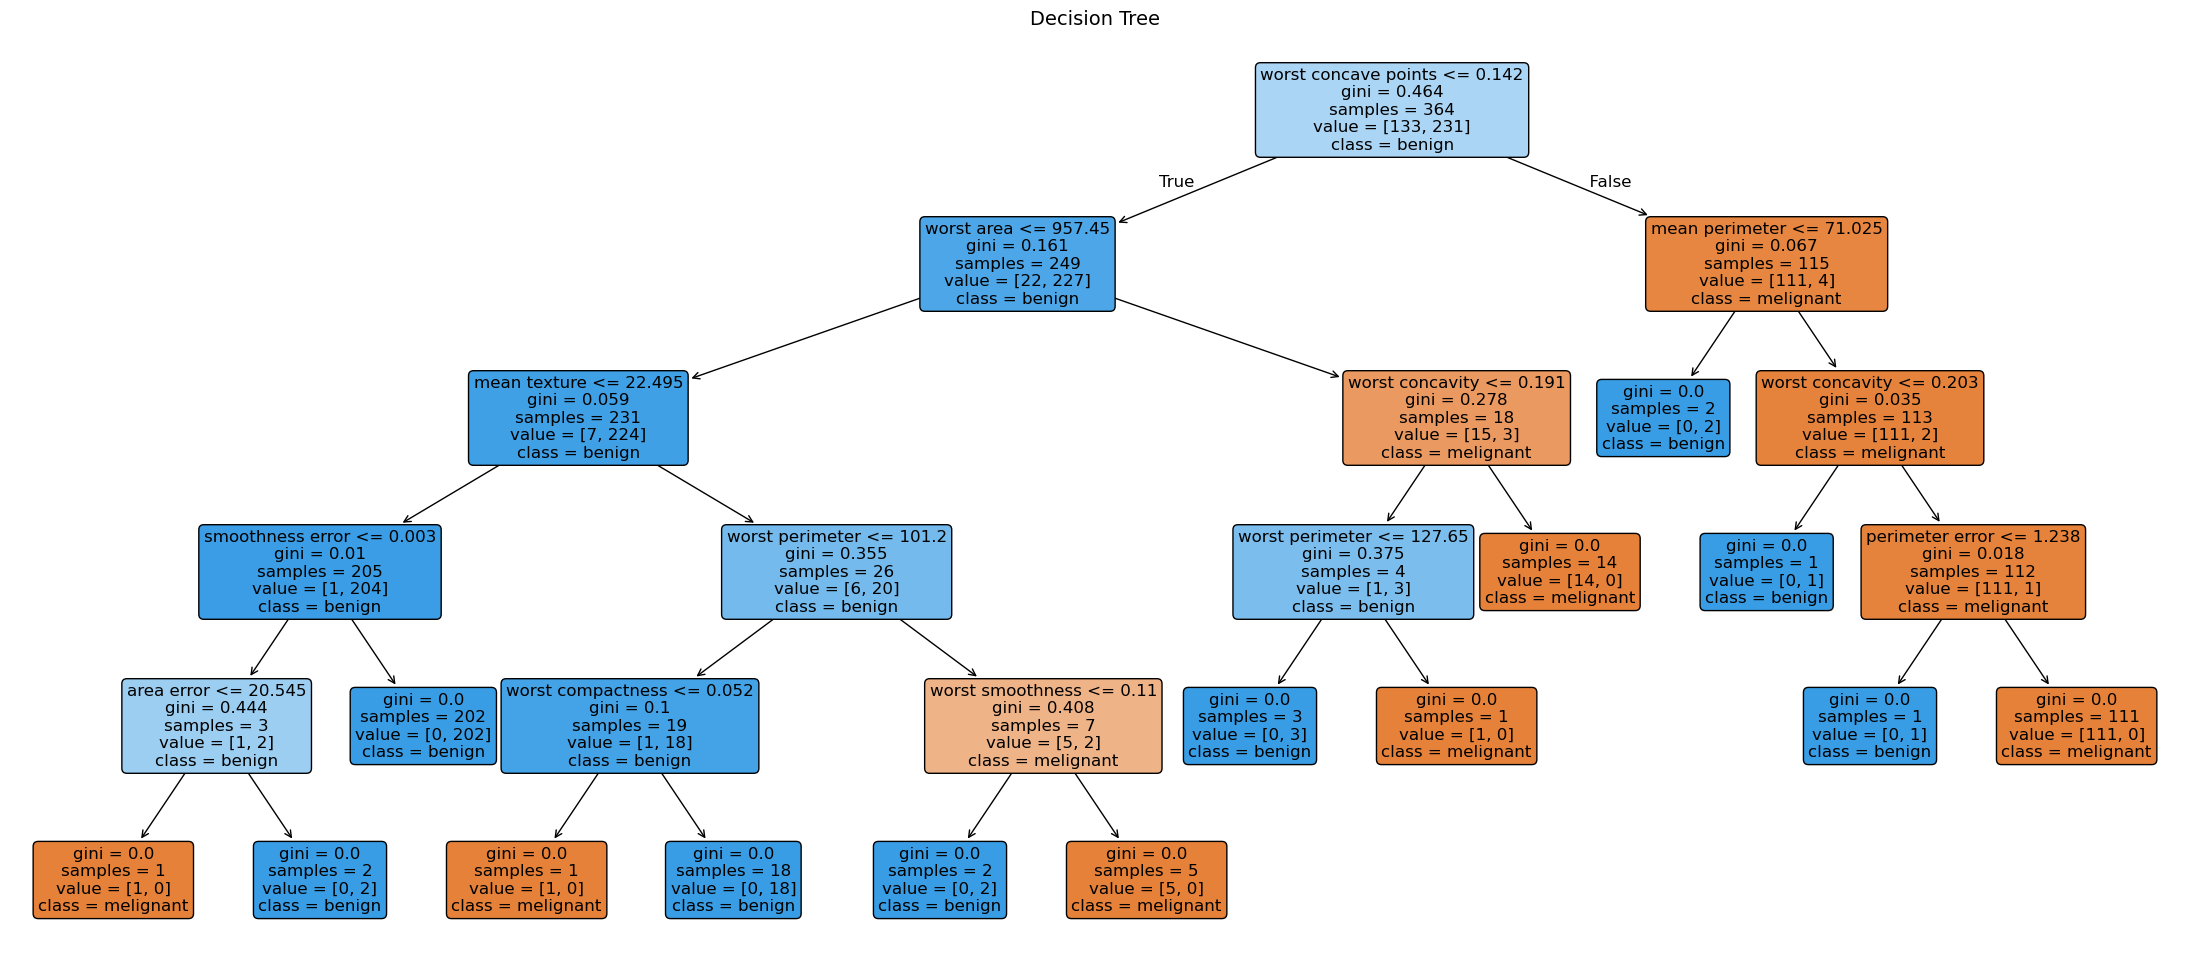

In [66]:
_, ax = plt.subplots(figsize=(28, 12))

plot_tree(
    decision_tree=tree,
    filled=True,
    feature_names=X.columns,
    class_names=["melignant", "benign"],
    fontsize=12,
    # proportion=True,
    rounded=True,
    ax=ax
)
ax.set_title("Decision Tree", fontsize=14)
plt.show()

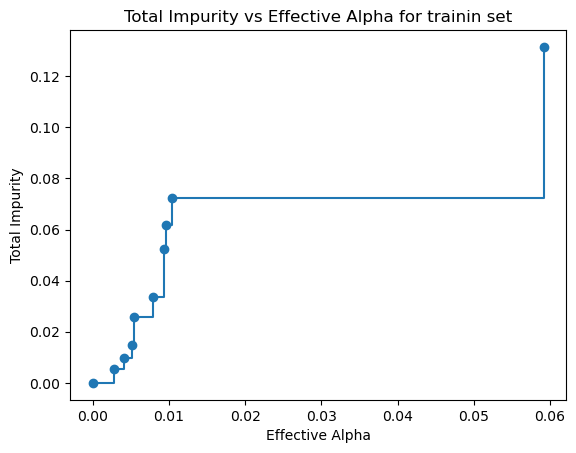

In [67]:
# post-pruning
path = tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

_, ax = plt.subplots()

ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")

ax.set(
    title="Total Impurity vs Effective Alpha for trainin set",
    ylabel="Total Impurity",
    xlabel="Effective Alpha"
)
plt.show()

In [71]:
# train models with different ccp_alpha
trees = []
for ccp_alpha in ccp_alphas:
    tree = DecisionTreeClassifier(criterion="gini", random_state=42, ccp_alpha=ccp_alpha)
    tree.fit(X_train, y_train)
    trees.append(tree)

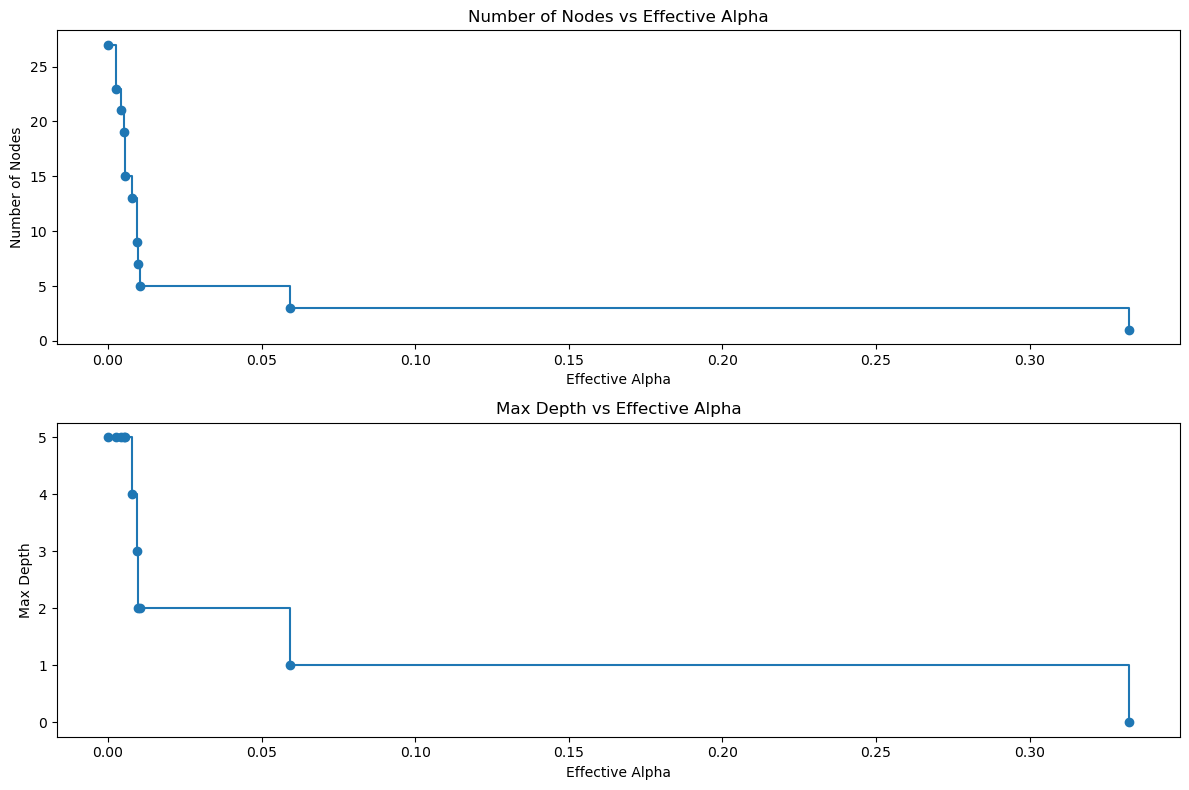

In [86]:
n_nodes = [tree.tree_.node_count for tree in trees]
trees_depths = [tree.tree_.max_depth for tree in trees]

_, (ax1, ax2) = plt.subplots(nrows=2, figsize=(12, 8))

ax1.plot(ccp_alphas, n_nodes, marker="o", drawstyle="steps-post")
ax1.set(
    title="Number of Nodes vs Effective Alpha",
    ylabel="Number of Nodes",
    xlabel="Effective Alpha"
)

ax2.plot(ccp_alphas, trees_depths, marker="o", drawstyle="steps-post")
ax2.set(
    title="Max Depth vs Effective Alpha",
    ylabel="Max Depth",
    xlabel="Effective Alpha"
)

plt.tight_layout()
plt.show()

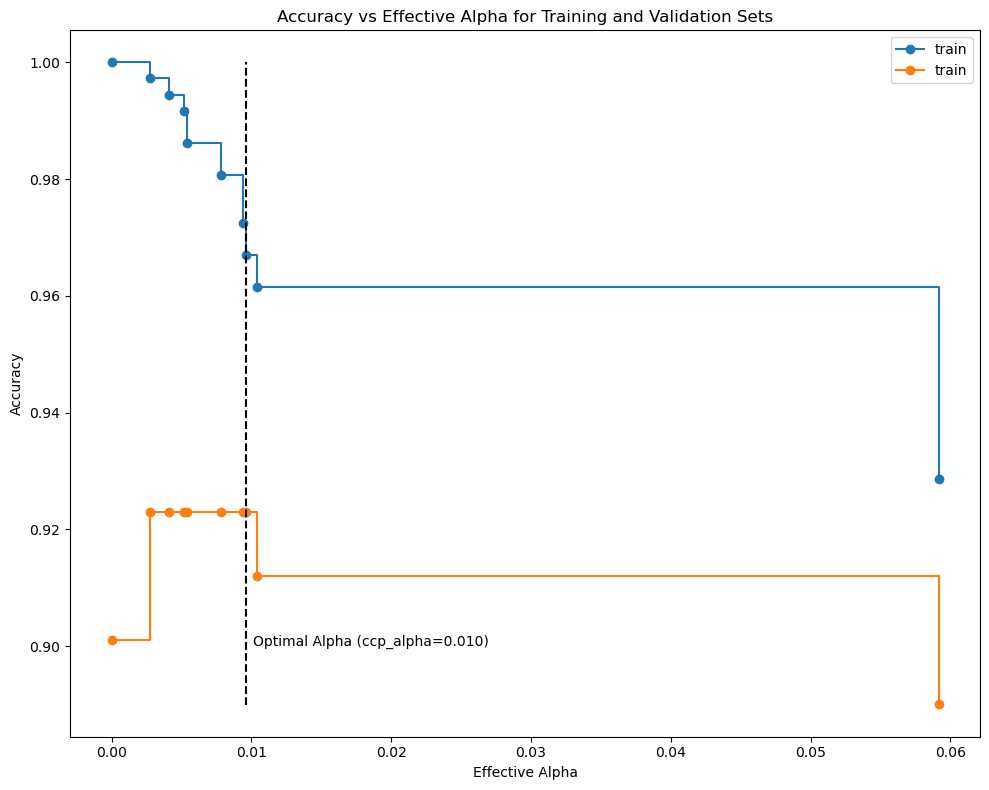

In [117]:
train_scores = [tree.score(X_train, y_train) for tree in trees]
val_scores = [tree.score(X_val, y_val) for tree in trees]

_, ax = plt.subplots(figsize=(10, 8))

ax.plot(ccp_alphas[:-1], train_scores[:-1], marker="o", drawstyle="steps-post", label="train")
ax.plot(ccp_alphas[:-1], val_scores[:-1], marker="o", drawstyle="steps-post", label="train")

ax.set(
    title="Accuracy vs Effective Alpha for Training and Validation Sets",
    ylabel="Accuracy",
    xlabel="Effective Alpha"
)

ax.vlines(ccp_alphas[-4], ymin=0.89, ymax=1, color="black", linestyle="--")
ax.text(x=ccp_alphas[-4] + 0.0005, y=0.9, s=f"Optimal Alpha (ccp_alpha={ccp_alphas[-4]:.3f})", color="black")

plt.tight_layout()
plt.legend()
plt.show()

In [120]:
tree = DecisionTreeClassifier(criterion='gini', random_state=42, ccp_alpha=0.01)
tree.fit(X_train, y_train)

print(f"Training Score: {tree.score(X_train, y_train)}")
print(f"Validation Score: {tree.score(X_val, y_val)}")
print("-" * 50)
print(f"Testing Score: {tree.score(X_test, y_test)}")

Training Score: 0.967032967032967
Validation Score: 0.9230769230769231
--------------------------------------------------
Testing Score: 0.9473684210526315


In [140]:
# cross-validation
from sklearn.model_selection import cross_val_score

score_cv = cross_val_score(tree, X, y, cv=5)

print(f"Mean CV score: {score_cv.mean():.2f}")
print(f"Std CV score: {score_cv.std():.2f}")

Mean CV score: 0.93
Std CV score: 0.01


In [143]:
print(classification_report(y_test, tree.predict(X_test)))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        47
           1       0.97      0.97      0.97        67

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



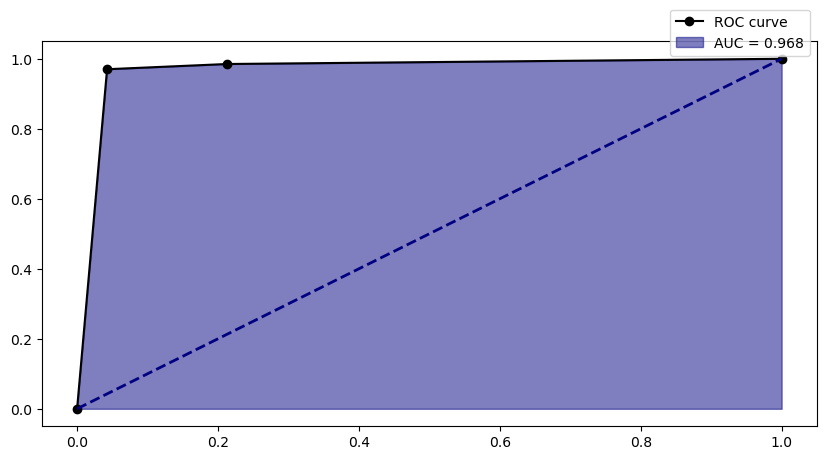

In [168]:
from sklearn.metrics import roc_curve, roc_auc_score

_, ax = plt.subplots(figsize=(10, 5))

fpr, tpr, thresholds = roc_curve(y_test, tree.predict_proba(X_test)[:, 1])
ax.plot(
    fpr, tpr,
    label=f'ROC curve', color='black',
    marker='o'
)
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax.fill_between(fpr, tpr, alpha=.5, color='navy', label='AUC = %.3f' % roc_auc_score(y_test, tree.predict_proba(X_test)[:, 1]))

ax.legend(loc='upper right', bbox_to_anchor=(1.0, 1.1))
plt.show()